In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
def vdp(x: np.ndarray, u: float, lam: float) -> np.ndarray:  # vanderpol equations
    x1, x2 = x
    
    dx1 = x2
    dx2 = -x1 + lam*(1 - x1**2) * x2 + u

    return np.array([dx1, dx2])


In [3]:
def g_vdp(x: np.ndarray, u: float, sigma: float) -> np.ndarray:
    return np.array([
        [0.0, 0.0],
        [0.0, sigma]
    ])

In [4]:
def f_aug(z:np.ndarray, u: float) -> np.ndarray:
    """
    z = [x1, x2, lam]
    """
    x1, x2, lam = z
    dz1 = x2
    dz2 = -x1 + lam * (1 - x1**2) * x2 + u
    dlam = 0.0

    return np.array([dz1, dz2, dlam], dtype=float)

In [5]:
def h_aug(z: np.ndarray) -> np.ndarray:
    """
    Only x1 and x2 are measured, lambda is not directly measured
    """
    return z[:2].copy()

In [6]:
def h_meas(x: np.ndarray) -> np.ndarray:
    return x.copy()

In [7]:

def C_aug_jacobian(z: np.ndarray) -> np.ndarray:
    """
    Jacobian of h_aug with respect to z
    shape 2x3
    """
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0]
    ], dtype=float)

In [8]:
def A_aug_jacobian(z: np.ndarray) -> np.ndarray:
    """
    Jacobian of f_aug with respect to z
    shape 3x3
    """
    x1, x2, lam = z
    return np.array([
        [0.0, 1.0, 0.0],
        [-1.0 -2.0 * lam * x1 * x2, lam * (1.0 - x1**2), (1.0 - x1**2) * x2],
        [0.0, 0.0, 0.0]
    ], dtype=float)

In [9]:
def ekf_predict_aug_state(z_hat: np.ndarray, u: float, Ts: float) -> np.ndarray:
    dz = f_aug(z_hat, u)
    return z_hat + dz * Ts

In [10]:
def ekf_aug_innovation(y: np.ndarray, z_pred: np.ndarray) -> np.ndarray:
    return y - h_aug(z_pred)

In [11]:
def ekf_aug_gain(P_pred: np.ndarray, z_pred: np.ndarray, R: np.ndarray) -> np.ndarray:
    C = C_aug_jacobian(z_pred)
    S = C @ P_pred @ C.T + R
    K = P_pred @ C.T @ np.linalg.inv(S)
    
    return K

In [12]:
def ekf_aug_update_state(z_pred: np.ndarray, K: np.ndarray, e: np.ndarray) -> np.ndarray:
    return z_pred + K @ e

In [13]:
def ekf_aug_update_cov(P_pred: np.ndarray, K: np.ndarray, z_pred: np.ndarray) -> np.ndarray:
    C = C_aug_jacobian(z_pred)
    I = np.eye(len(z_pred))
    return (I - K @ C) @ P_pred

In [14]:
def ekf_predict_aug_cov(P: np.ndarray, z_pred: np.ndarray, Q: np.ndarray, Ts: float) -> np.ndarray:
    A = A_aug_jacobian(z_pred)
    F = np.eye(len(z_pred)) + A * Ts
    return F @ P @ F.T + Q

In [15]:
def solve_nmpc(
    x0: np.ndarray,
    lam_hat: float,
    N: int,
    dt: float,
    t0: float
):
    """
    Solve NMPC optimization at time t0.
    """

    # initial guess
    u0 = np.zeros(N)

    # bounds: -1 ≤ u ≤ 1
    bounds = [(-1.0, 1.0)] * N

    result = minimize(
        nmpc_objective,
        u0,
        args=(x0, lam_hat, dt, t0),
        method='L-BFGS-B',
        bounds=bounds
    )

    u_opt = result.x

    return u_opt

In [16]:
def forward_simulation(
    x0: np.ndarray,
    lam_hat: float,
    u_seq: np.ndarray,
    dt: float
) -> np.ndarray:
    """
    Simulate system forward using a control sequence.

    x0: initial state (from EKF)
    lam_hat: estimated parameter
    u_seq: control sequence (length N)
    dt: integration step

    return:
        x_traj: shape (N+1, 2)
    """

    N = len(u_seq)

    x_traj = np.zeros((N + 1, 2))
    x_traj[0] = x0

    for k in range(N):
        x_k = x_traj[k]
        u_k = u_seq[k]

        dx = vdp(x_k, u_k, lam_hat)

        x_traj[k + 1] = x_k + dx * dt

    return x_traj

In [17]:
def reference_x1(t: float) -> float:
    """
    Set-point (reference) for x1.
    """
    if t <= 15.0:
        return 0.0
    elif t <= 30.0:
        return 1.0
    else:
        return 0.0

In [18]:

def stage_cost(x: np.ndarray, u: float, t: float, alpha: float = 0.02) -> float:
    """
    Stage cost l(x,u,t)

    x: state [x1, x2]
    u: control input
    t: time
    """

    x1 = x[0]
    r = reference_x1(t)

    tracking_error = (x1 - r)**2
    control_effort = u**2

    return (1 - alpha) * tracking_error + alpha * control_effort

In [19]:
def compute_cost(
    x0: np.ndarray,
    lam_hat: float,
    u_seq: np.ndarray,
    dt: float,
    t0: float,
    alpha: float = 0.02
) -> float:
    """
    Compute total cost over horizon.
    """

    x_traj = forward_simulation(x0, lam_hat, u_seq, dt)

    cost = 0.0

    for k in range(len(u_seq)):
        t_k = t0 + k * dt

        cost += stage_cost(x_traj[k], u_seq[k], t_k, alpha) * dt

    return cost

In [20]:
def nmpc_objective(
    u_seq_flat,
    x0,
    lam_hat,
    dt,
    t0,
    alpha=0.02
):
    """
    Objective function for NMPC optimizer.
    """
    u_seq = np.array(u_seq_flat)

    return compute_cost(
        x0=x0,
        lam_hat=lam_hat,
        u_seq=u_seq,
        dt=dt,
        t0=t0,
        alpha=alpha
    )


In [21]:
def plant_step_sde(
    x: np.ndarray,
    u: float,
    lam_true: float,
    sigma: float,
    Ts: float,
    rng: np.random.Generator
) -> np.ndarray:
    
    dx = vdp(x, u, lam_true)
    G = g_vdp(x, u, sigma)
    dw = rng.normal(loc=0.0, scale=np.sqrt(Ts), size=2)

    x_next = x + dx * Ts + G @ dw
    return x_next

In [22]:
def measurement_step(
    x_true: np.ndarray,
    sigma_eps: float,
    rng: np.random.Generator
) -> np.ndarray:
    
    noise = rng.normal(loc=0.0, scale=sigma_eps, size=2)
    return h_meas(x_true) + noise

In [23]:
def run_closed_loop_nmpc(
    x0_true: np.ndarray,
    z0_hat: np.ndarray,
    P0: np.ndarray,
    n_steps: int,
    Ts: float,
    sigma: float,
    sigma_eps: float,
    lam_true,
    Q: np.ndarray,
    R: np.ndarray,
    N_pred: int,
    dt_pred: float,
    rng_seed: int=42
):
    """
    Closed-loop simulation:
    Plant -> Measurement -> Augmented EKF -> NMPC -> Control -> Plant

    Parameters
    ----------
    x0_true: True initial state [x1, x2]
    z0_hat: Initial augmented estimate [x1_hat, x2_hat, lam_hat]
    P0: Initial covariance (3x3)
    n_steps: Number of closed-loop sampling times
    Ts: sample time
    sigma: Plant process noise intensity
    sigma_eps: Measurement noise std
    lam_true: Can be a constant or a function
    Q,R: EKF covariance matrices
    N_pred: predict horizon - number of control moves
    dt_pred: prediction step inside NMPC model
    rng_seed: RNG seed

    Returns
    -------
    dict: Trajectories and logs
    """

    rng = np.random.default_rng(rng_seed)

    # logs
    x_true_hist = np.zeros((n_steps, 2))
    y_hist = np.zeros((n_steps, 2))
    z_hat_hist = np.zeros((n_steps, 3))
    u_hist = np.zeros(n_steps)

    # init
    x_true = x0_true.copy()
    z_hat = z0_hat.copy()
    P = P0.copy()

    x_true_hist[0] = x_true
    y_hist[0] = measurement_step(x_true, sigma_eps, rng)
    z_hat_hist[0] = z_hat
    u_hist[0] = 0.0

    for k in range(1, n_steps):
        t_k = k * Ts

        #---- Measurement from current plant
        y_k = measurement_step(x_true, sigma_eps, rng)

        #---- EKF update/predict cycle
        u_prev = u_hist[k-1]

        #---- Predict
        z_pred = ekf_predict_aug_state(z_hat, u_prev, Ts)
        P_pred = ekf_predict_aug_cov(P, z_pred, Q, Ts)

        #---- Update
        e = ekf_aug_innovation(y_k, z_pred)
        K = ekf_aug_gain(P_pred, z_pred, R)

        z_hat = ekf_aug_update_state(z_pred, K, e)
        P = ekf_aug_update_cov(P_pred, K, z_pred)

        #---- NMPC solve using estimated state and lambda
        x_est_for_mpc = z_hat[:2]
        lam_est_for_mpc = z_hat[2]

        u_opt = solve_nmpc(
            x0=x_est_for_mpc,
            lam_hat=lam_est_for_mpc,
            N=N_pred,
            dt=dt_pred,
            t0=t_k
        )
        u_k = u_opt[0]

        #---- Apply control to true plant
  
        if callable(lam_true):
            lam_k = lam_true(k, t_k)
        else:
            lam_k = lam_true

        x_true = plant_step_sde(
            x=x_true,
            u=u_k,
            lam_true=lam_k,
            sigma=sigma,
            Ts=Ts,
            rng=rng
        )

        #---- Log everything

        x_true_hist[k] = x_true
        y_hist[k] = y_k
        z_hat_hist[k] = z_hat
        u_hist[k] = u_k

    return {
        "x_true": x_true_hist,
        "y_meas": y_hist,
        "z_hat": z_hat_hist,
        "u": u_hist
    }

In [24]:
def plot_closed_loop(
    results: dict,
    Ts: float,
    lam_true,
):
    x_true = results["x_true"]
    y_meas = results["y_meas"]
    z_hat = results["z_hat"]
    u_hist = results["u"]

    n_steps = len(x_true)
    t = np.arange(n_steps) * Ts

    # lambda true array
    if callable(lam_true):
        lam_true_arr = np.array([lam_true(k, k * Ts) for k in range(n_steps)])
    else:
        lam_true_arr = np.full(n_steps, lam_true)

    # reference
    ref = np.array([reference_x1(tt) for tt in t])

    # ===== layout 2x2 =====
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # =========================
    # (1) x1 tracking (top-left)
    # =========================
    ax = axes[0, 0]
    # ax.plot(t, x_true[:, 0], label="x1 true", linewidth=2)
    # ax.plot(t, y_meas[:, 0], ".", label="measurement", alpha=0.4)
    ax.plot(t, z_hat[:, 0], label="x1 estimated", linewidth=2)
    ax.plot(t, ref, "--", label="reference", linewidth=2)

    ax.set_title("x1 tracking")
    ax.legend()
    ax.grid()

    # =========================
    # (2) control (top-right)
    # =========================
    ax = axes[0, 1]
    ax.plot(t, u_hist, label="u", linewidth=2)
    ax.axhline(1.0, linestyle="--")
    ax.axhline(-1.0, linestyle="--")

    ax.set_title("Control input")
    ax.legend()
    ax.grid()

    # =========================
    # (3) phase plane (bottom-left)
    # =========================
    ax = axes[1, 0]
    ax.plot(x_true[:, 0], x_true[:, 1], label="true", linewidth=2)
    ax.plot(z_hat[:, 0], z_hat[:, 1], label="estimated", linewidth=2)

    ax.set_title("Phase plane")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.grid()

    # =========================
    # (4) lambda (bottom-right)
    # =========================
    ax = axes[1, 1]
    ax.plot(t, lam_true_arr, label="lambda true", linewidth=2)
    ax.plot(t, z_hat[:, 2], label="lambda estimated", linewidth=2)

    ax.set_title("Parameter estimation")
    ax.legend()
    ax.grid()
    plt.tight_layout()
    plt.show()

Running ...


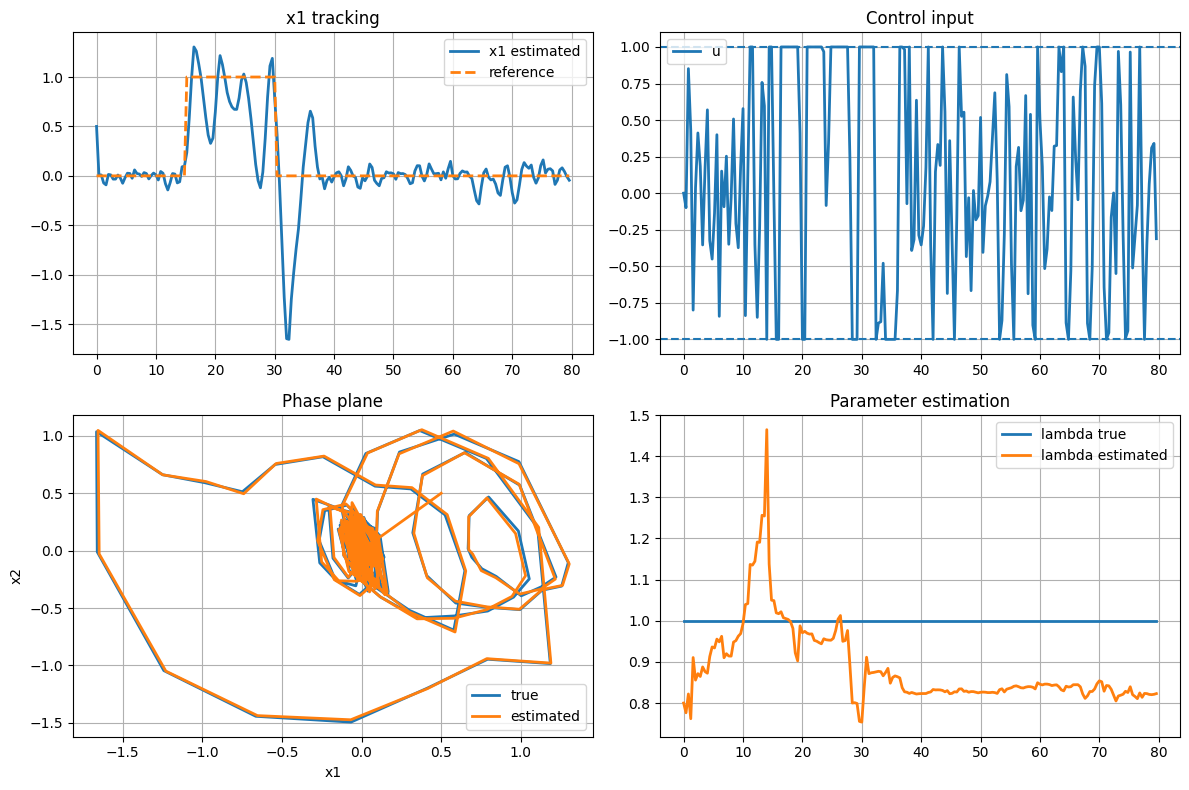

In [25]:
# True plant settings
lam_true = 1.0
sigma = 0.2
sigma_eps = 0.015

# EKF init
z0_hat = np.array([0.5, 0.5, 0.8], dtype=float)
P0 = np.eye(3)

sigma_lam = 0.02
Q = np.array([
    [1e-6,      0.0,       0.0],
    [0.0, sigma**2,       0.0],
    [0.0,      0.0, sigma_lam**2]
], dtype=float)

R = sigma_eps**2 * np.eye(2)

# Closed-loop settings
x0_true = np.array([0.0, 0.0], dtype=float)
Ts = 0.4
n_steps = 200

# NMPC settings
N_pred = 20
dt_pred = 0.2

print("Running ...")
results = run_closed_loop_nmpc(
    x0_true=x0_true,
    z0_hat=z0_hat,
    P0=P0,
    n_steps=n_steps,
    Ts=Ts,
    sigma=sigma,
    sigma_eps=sigma_eps,
    lam_true=lam_true,
    Q=Q,
    R=R,
    N_pred=N_pred,
    dt_pred=dt_pred,
    rng_seed=42
)

plot_closed_loop(results, Ts=Ts, lam_true=lam_true)